# Dynamical Systems: Pendulum Trajectory Surrogate

Fit a small-angle pendulum surrogate from initial state and time to angular displacement. The quantum regressor is assembled from package embedding, ansatz, optimizer, training-loop, and metric utilities, then compared with a ridge baseline.

## Problem, Variables, and Quantum Advantage Context

**Physics problem.** The small-angle pendulum is a canonical dynamical system with an analytic trajectory. The notebook learns a supervised surrogate that predicts angular displacement from initial conditions and time.

**Explicit variables.** `theta0` is the initial angular displacement. `omega0` is the initial angular velocity. `time` is the evaluation time. In nondimensional units, the target is `theta(t) = theta0 cos(time) + omega0 sin(time)`. `x_raw = [theta0, omega0, time]` is the feature vector. `y_raw = theta(t)` is the regression target. `x_train`, `x_test`, `y_train`, and `y_test` are the train/test splits. `q_test_pred` and `ridge_test_pred` are held-out predictions from the quantum regressor and ridge baseline.

**Quantum advantage context.** Variational quantum regressors can provide nonlinear feature maps through parameterized quantum circuits. In larger or higher-dimensional dynamical systems, this may offer useful expressive representations. This small analytic example does **not** establish quantum advantage; it checks whether the package can train a compact quantum surrogate and compare it against a classical baseline.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "real_examples":
    repo_root = repo_root.parents[1]
elif repo_root.name == "notebooks":
    repo_root = repo_root.parent

package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

import numpy as np
import pennylane as pl
from pennylane import numpy as pnp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

from qml.ansatz import apply_hardware_efficient_ansatz, parameter_shape
from qml.embeddings import apply_angle_embedding
from qml.metrics import mean_absolute_error, mean_squared_error
from qml.optimizers import get_optimizer
from qml.training import run_training_loop

import matplotlib.pyplot as plt
from qml.reporting import print_section


## Domain simulator

For the small-angle pendulum, `theta(t) = theta0 cos(t) + omega0 sin(t)` in nondimensional units. The supervised task is to learn `theta(t)` from `(theta0, omega0, t)`.

In [2]:
rng = np.random.default_rng(11)
n_samples = 54
theta0 = rng.uniform(-0.6, 0.6, size=n_samples)
omega0 = rng.uniform(-0.45, 0.45, size=n_samples)
time = rng.uniform(0.0, 2.5 * np.pi, size=n_samples)

y_raw = theta0 * np.cos(time) + omega0 * np.sin(time)
x_raw = np.column_stack([theta0, omega0, time])

x_train, x_test, y_train, y_test = train_test_split(x_raw, y_raw, test_size=0.3, random_state=11)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print_section(
    "Dataset",
    [
        ("Samples", int(n_samples)),
        ("feature_shape", list(x_raw.shape)),
        ("Target range", [float(y_raw.min()), float(y_raw.max())]),
    ],
)

Dataset
+---------------+----------------------+
| Metric        | Value                |
+---------------+----------------------+
| Samples       | 54                   |
| feature_shape | [54, 3]              |
| Target range  | [-0.57019, 0.562638] |
+---------------+----------------------+



## System visualization

A direct plot of the simulated physical or mathematical system before fitting any machine-learning model.

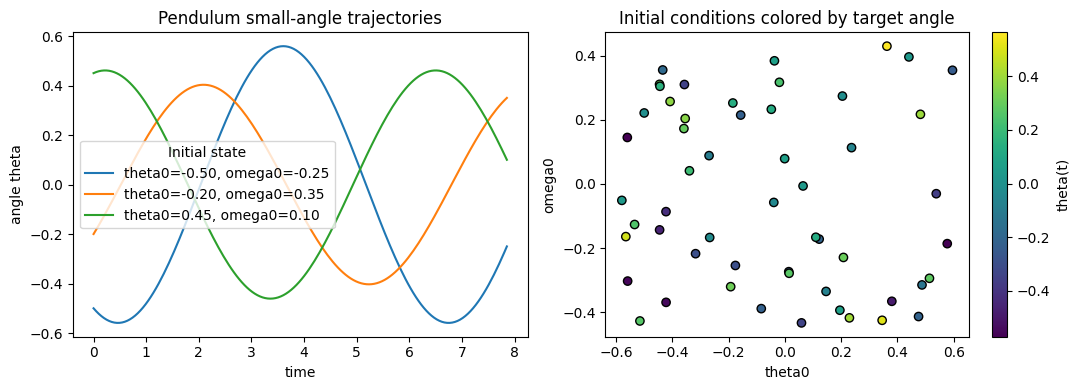

In [3]:
time_grid = np.linspace(0.0, 2.5 * np.pi, 160)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for th0, om0 in [(-0.5, -0.25), (-0.2, 0.35), (0.45, 0.1)]:
    theta_path = th0 * np.cos(time_grid) + om0 * np.sin(time_grid)
    axes[0].plot(time_grid, theta_path, label=f"theta0={th0:.2f}, omega0={om0:.2f}")
axes[0].set_title("Pendulum small-angle trajectories")
axes[0].set_xlabel("time")
axes[0].set_ylabel("angle theta")
axes[0].legend(title="Initial state")
scatter = axes[1].scatter(theta0, omega0, c=y_raw, cmap="viridis", edgecolor="black")
axes[1].set_title("Initial conditions colored by target angle")
axes[1].set_xlabel("theta0")
axes[1].set_ylabel("omega0")
fig.colorbar(scatter, ax=axes[1], label="theta(t)")
plt.tight_layout()
plt.show()


## Package-client quantum regressor

In [4]:
def train_small_vqr(x_train, y_train, *, seed, n_layers=2, steps=70, step_size=0.08):
    n_qubits = x_train.shape[1]
    wires = list(range(n_qubits))
    dev = pl.device("default.qubit", wires=n_qubits, seed=seed)

    @pl.qnode(dev, interface="autograd")
    def circuit(sample, params):
        apply_angle_embedding(sample, wires=wires)
        apply_hardware_efficient_ansatz(params, wires=wires)
        return pl.expval(pl.PauliZ(wires[0]))

    def predict_batch(samples, params):
        return pnp.array([circuit(sample, params) for sample in samples])

    def cost(params):
        preds = predict_batch(x_train, params)
        return pnp.mean((preds - pnp.asarray(y_train, dtype=float)) ** 2)

    rng = np.random.default_rng(seed)
    init = 0.01 * rng.standard_normal(parameter_shape(n_layers=n_layers, n_qubits=n_qubits))
    params = pnp.array(init, requires_grad=True)
    opt = get_optimizer("adam", stepsize=step_size)

    def step_fn(current_params):
        return opt.step_and_cost(cost, current_params)

    params, loss_history = run_training_loop(step_fn, params, steps)

    def predict(samples):
        return np.asarray(predict_batch(samples, params), dtype=float)

    return params, loss_history, predict

In [5]:
params, loss_history, predict = train_small_vqr(
    x_train, y_train, seed=11, n_layers=2, steps=75, step_size=0.07
)

q_train_pred = predict(x_train)
q_test_pred = predict(x_test)

ridge = Ridge(alpha=1e-3)
ridge.fit(x_train, y_train)
ridge_test_pred = ridge.predict(x_test)

results = {
    "quantum_test_mae": mean_absolute_error(y_test, q_test_pred),
    "quantum_test_mse": mean_squared_error(y_test, q_test_pred),
    "ridge_test_mae": mean_absolute_error(y_test, ridge_test_pred),
    "initial_loss": float(loss_history[0]),
    "final_loss": float(loss_history[-1]),
    "loss_steps": len(loss_history),
}
print_section(
    "Results",
    [
        ("Quantum test MAE", results["quantum_test_mae"]),
        ("Quantum test MSE", results["quantum_test_mse"]),
        ("Ridge test MAE", results["ridge_test_mae"]),
        ("Initial loss", results["initial_loss"]),
        ("Final loss", results["final_loss"]),
        ("Loss steps", results["loss_steps"]),
    ],
)

Results
+------------------+-----------+
| Metric           | Value     |
+------------------+-----------+
| Quantum test MAE | 0.241666  |
| Quantum test MSE | 0.0977921 |
| Ridge test MAE   | 0.261172  |
| Initial loss     | 0.557283  |
| Final loss       | 0.0745353 |
| Loss steps       | 75        |
+------------------+-----------+



## Plots

The plots show the simulated samples, quantum-regressor training loss, and held-out predicted-vs-actual trajectory values.

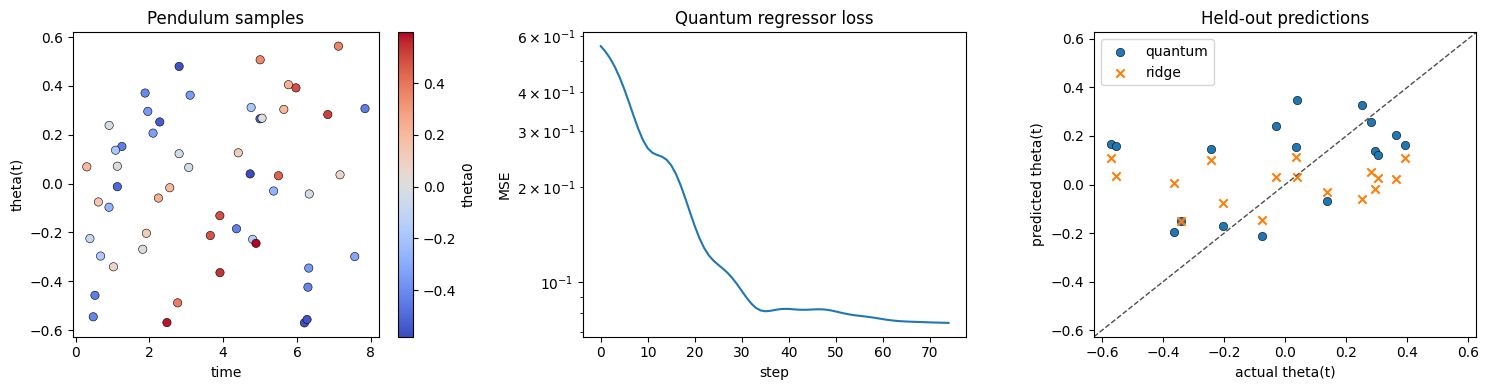

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

scatter = axes[0].scatter(time, y_raw, c=theta0, cmap="coolwarm", edgecolor="black", linewidth=0.4)
axes[0].set_title("Pendulum samples")
axes[0].set_xlabel("time")
axes[0].set_ylabel("theta(t)")
fig.colorbar(scatter, ax=axes[0], label="theta0")

axes[1].plot(loss_history, color="tab:blue")
axes[1].set_title("Quantum regressor loss")
axes[1].set_xlabel("step")
axes[1].set_ylabel("MSE")
axes[1].set_yscale("log")

limit = (
    max(np.max(np.abs(y_test)), np.max(np.abs(q_test_pred)), np.max(np.abs(ridge_test_pred))) * 1.1
)
axes[2].scatter(y_test, q_test_pred, label="quantum", edgecolor="black", linewidth=0.4)
axes[2].scatter(y_test, ridge_test_pred, label="ridge", marker="x")
axes[2].plot([-limit, limit], [-limit, limit], color="0.3", linestyle="--", linewidth=1)
axes[2].set_xlim(-limit, limit)
axes[2].set_ylim(-limit, limit)
axes[2].set_title("Held-out predictions")
axes[2].set_xlabel("actual theta(t)")
axes[2].set_ylabel("predicted theta(t)")
axes[2].legend()

fig.tight_layout()
plt.show()

## Validation block

This final cell confirms the notebook learned a finite, non-trivial pendulum surrogate and reports sample predictions in physical units.

In [7]:
validation = {
    "dataset": {
        "problem": "small_angle_pendulum_trajectory_surrogate",
        "features": ["theta0", "omega0", "time"],
        "target": "theta_at_time",
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
    },
    "results": results,
    "sample_predictions": [
        {"actual": float(a), "quantum": float(q), "ridge": float(r)}
        for a, q, r in zip(y_test[:6], q_test_pred[:6], ridge_test_pred[:6])
    ],
    "passed": bool(
        np.isfinite(q_test_pred).all()
        and results["final_loss"] < results["initial_loss"]
        and results["quantum_test_mae"] < 0.65
    ),
}

print("Validation")
print_section(
    "Dataset",
    [
        ("Problem", validation["dataset"]["problem"]),
        ("Features", validation["dataset"]["features"]),
        ("Target", validation["dataset"]["target"]),
        ("Train samples", validation["dataset"]["n_train"]),
        ("Test samples", validation["dataset"]["n_test"]),
    ],
)
print_section(
    "Results",
    [
        ("Quantum test MAE", validation["results"]["quantum_test_mae"]),
        ("Quantum test MSE", validation["results"]["quantum_test_mse"]),
        ("Ridge test MAE", validation["results"]["ridge_test_mae"]),
        ("Initial loss", validation["results"]["initial_loss"]),
        ("Final loss", validation["results"]["final_loss"]),
        ("Loss steps", validation["results"]["loss_steps"]),
    ],
)
print("Sample predictions")
for index, row in enumerate(validation["sample_predictions"], start=1):
    print(
        f"{index}. Actual: {row['actual']:.6f}, "
        f"Quantum: {row['quantum']:.6f}, "
        f"Ridge: {row['ridge']:.6f}"
    )
print()
print("Interpretation")
print("The quantum regressor trained successfully and reduced the optimization loss.")
print(
    "The held-out error is reasonable for a compact illustrative surrogate, but individual predictions can still be visibly imperfect."
)
print("The ridge baseline is included as a sanity benchmark; no quantum advantage is claimed.")
print()
print(f"Passed: {validation['passed']}")
assert validation["passed"]

Validation
Dataset
+---------------+-------------------------------------------+
| Metric        | Value                                     |
+---------------+-------------------------------------------+
| Problem       | small_angle_pendulum_trajectory_surrogate |
| Features      | [theta0, omega0, time]                    |
| Target        | theta_at_time                             |
| Train samples | 37                                        |
| Test samples  | 17                                        |
+---------------+-------------------------------------------+

Results
+------------------+-----------+
| Metric           | Value     |
+------------------+-----------+
| Quantum test MAE | 0.241666  |
| Quantum test MSE | 0.0977921 |
| Ridge test MAE   | 0.261172  |
| Initial loss     | 0.557283  |
| Final loss       | 0.0745353 |
| Loss steps       | 75        |
+------------------+-----------+

Sample predictions
1. Actual: -0.340563, Quantum: -0.148739, Ridge: -0.148951
2. Ac